Collaborative filtering relies solely on user-item interactions within the utility matrix. The issue with this approach is that brand new users or items with no interactions get excluded from the recommendation system. This is called the "cold start" problem. Content-based filtering is a way to handle this problem by generating recommendations based on user and item features.

Here will generate item-item recommendations using content-based filtering.

In [1]:
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
movies_df = pd.read_pickle('movies.pkl')
movies_df.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


* Here we will make the genres to a list instead of string seperated by '|'
* Also the movie is mentioned along with year of release, will seperaet it

In [3]:
movies_df['genres'] = movies_df['genres'].apply(lambda x: x.split("|"))
movies_df.head()

,movieId,title,genres
0,1,Toy Story (1995),"[Adventure, Animation, Children, Comedy, Fantasy]"
1,2,Jumanji (1995),"[Adventure, Children, Fantasy]"
2,3,Grumpier Old Men (1995),"[Comedy, Romance]"
3,4,Waiting to Exhale (1995),"[Comedy, Drama, Romance]"
4,5,Father of the Bride Part II (1995),[Comedy]


In [4]:
from collections import Counter

genres_counts = Counter(g for genres in movies_df['genres'] for g in genres)
print(f"There are {len(genres_counts)} genre labels.")
genres_counts

There are 20 genre labels.


Counter({'Adventure': 1263,
         'Animation': 611,
         'Children': 664,
         'Comedy': 3756,
         'Fantasy': 779,
         'Romance': 1596,
         'Drama': 4361,
         'Action': 1828,
         'Crime': 1199,
         'Thriller': 1894,
         'Horror': 978,
         'Mystery': 573,
         'Sci-Fi': 980,
         'War': 382,
         'Musical': 334,
         'Documentary': 440,
         'IMAX': 158,
         'Western': 167,
         'Film-Noir': 87,
         '(no genres listed)': 34})

In [5]:
movies_df = movies_df[movies_df['genres']!='(no genres listed)']

del genres_counts['(no genres listed)']

In [6]:
genres_counts.most_common(5)

[('Drama', 4361),
 ('Comedy', 3756),
 ('Thriller', 1894),
 ('Action', 1828),
 ('Romance', 1596)]

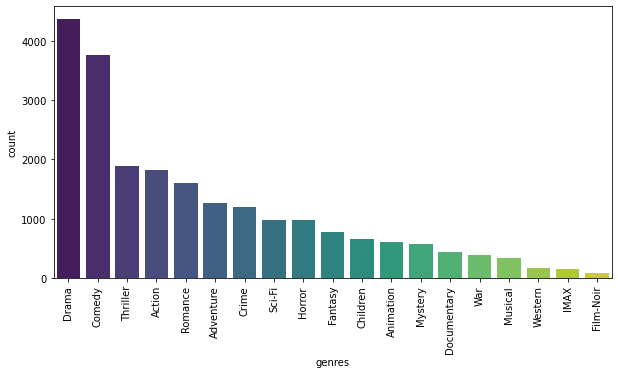

In [7]:
genres_counts_df = pd.DataFrame([genres_counts]).T.reset_index()
genres_counts_df.columns = ['genres', 'count']
genres_counts_df = genres_counts_df.sort_values(by='count', ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x='genres', y='count', data=genres_counts_df, palette='viridis')
plt.xticks(rotation=90)
plt.show()

In [8]:
import re 

def extract_year_from_title(title):
    t = title.split(' ')
    year = None
    if re.search(r'\(\d+\)', t[-1]):
        year = t[-1].strip('()')
        year = int(year)
    return year

In [9]:
title = "Father of the Bride Part II (1995)"
year = extract_year_from_title(title)
print(f"Year of release: {year}")
print(type(year))

Year of release: 1995
<class 'int'>


In [10]:
movies_df['year'] = movies_df['title'].apply(extract_year_from_title)
movies_df.head()

,movieId,title,genres,year
0,1,Toy Story (1995),"[Adventure, Animation, Children, Comedy, Fantasy]",1995.0
1,2,Jumanji (1995),"[Adventure, Children, Fantasy]",1995.0
2,3,Grumpier Old Men (1995),"[Comedy, Romance]",1995.0
3,4,Waiting to Exhale (1995),"[Comedy, Drama, Romance]",1995.0
4,5,Father of the Bride Part II (1995),[Comedy],1995.0


##### How many different years of release are covered in our dataset?

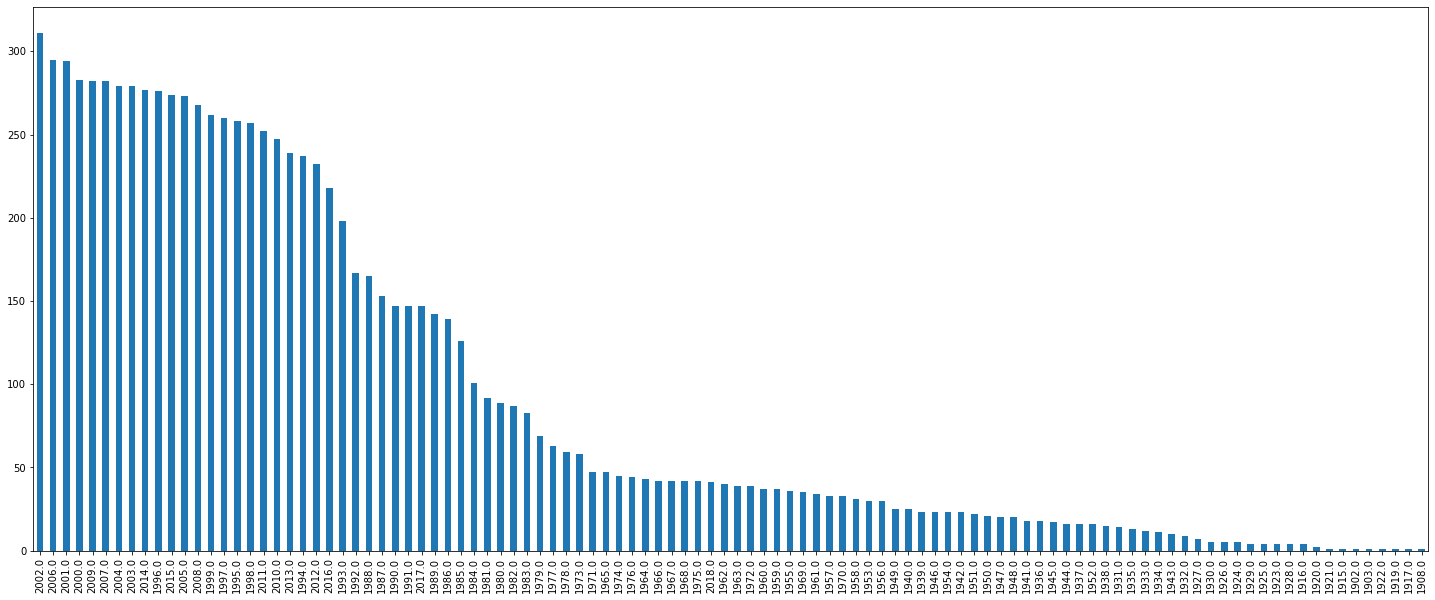

In [11]:
movies_df['year'].value_counts().plot(kind = 'bar', figsize = (25, 10))

 we'll remove all movies with null year.

In [12]:
print(f"Original number of movies: {movies_df['movieId'].nunique()}")

Original number of movies: 9742


In [13]:
movies_df = movies_df[~movies_df['year'].isnull()]
print(f"Number of movies after removing null years: {movies_df['movieId'].nunique()}")

Number of movies after removing null years: 9718


In [14]:
x = 1995

def get_decade(year):
    year = str(year)
    decade_prefix = year[0:3] # get first 3 digits of year
    decade = f'{decade_prefix}0' # append 0 at the end
    return int(decade)

get_decade(x)

1990

In [15]:
def round_down(year):
    return year - (year%10)

round_down(x)

1990

In [16]:
movies_df['decade'] = movies_df['year'].apply(round_down)
movies_df

,movieId,title,genres,year,decade
0,1,Toy Story (1995),"[Adventure, Animation, Children, Comedy, Fantasy]",1995.0,1990.0
1,2,Jumanji (1995),"[Adventure, Children, Fantasy]",1995.0,1990.0
2,3,Grumpier Old Men (1995),"[Comedy, Romance]",1995.0,1990.0
3,4,Waiting to Exhale (1995),"[Comedy, Drama, Romance]",1995.0,1990.0
4,5,Father of the Bride Part II (1995),[Comedy],1995.0,1990.0
...,...,...,...,...,...
9737,193581,Black Butler: Book of the Atlantic (2017),"[Action, Animation, Comedy, Fantasy]",2017.0,2010.0
9738,193583,No Game No Life: Zero (2017),"[Animation, Comedy, Fantasy]",2017.0,2010.0
9739,193585,Flint (2017),[Drama],2017.0,2010.0
9740,193587,Bungo Stray Dogs: Dead Apple (2018),"[Action, Animation]",2018.0,2010.0


(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11]),
 <a list of 12 Text major ticklabel objects>)

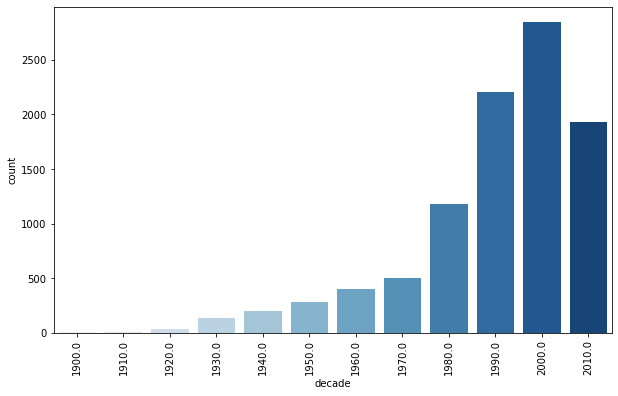

In [17]:
plt.figure(figsize=(10,6))
sns.countplot(movies_df['decade'], palette='Blues')
plt.xticks(rotation=90)

In order to build a content-based filtering recommender, we need to set up our dataset so that rows represent movies and columns represent features (i.e., genres and decades).

First, we need to manipulate the genres column so that each genre is represented as a separate binary feature. "1" indicates that the movie falls under a given genre, while "0" does not.

In [18]:
genres = list(genres_counts.keys())

for g in genres:
    movies_df[g] = movies_df['genres'].transform(lambda x: int(g in x))

In [19]:
movies_df[genres].head()

,Adventure,Animation,Children,Comedy,Fantasy,Romance,Drama,Action,Crime,Thriller,Horror,Mystery,Sci-Fi,War,Musical,Documentary,IMAX,Western,Film-Noir
0,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,1,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [20]:
movie_decades = pd.get_dummies(movies_df['decade'])
movie_decades.head()

,1900.0,1910.0,1920.0,1930.0,1940.0,1950.0,1960.0,1970.0,1980.0,1990.0,2000.0,2010.0
0,0,0,0,0,0,0,0,0,0,1,0,0
1,0,0,0,0,0,0,0,0,0,1,0,0
2,0,0,0,0,0,0,0,0,0,1,0,0
3,0,0,0,0,0,0,0,0,0,1,0,0
4,0,0,0,0,0,0,0,0,0,1,0,0


In [21]:
movie_features = pd.concat([movies_df[genres], movie_decades], axis=1)
movie_features.head()

,Adventure,Animation,Children,Comedy,Fantasy,Romance,Drama,Action,Crime,Thriller,...,1920.0,1930.0,1940.0,1950.0,1960.0,1970.0,1980.0,1990.0,2000.0,2010.0
0,1,1,1,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,1,0,1,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,0,0,0,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,0,0,0,1,0,1,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
4,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [22]:
from sklearn.metrics.pairwise import cosine_similarity

cosine_sim = cosine_similarity(movie_features, movie_features)
print(f"Dimensions of our movie features cosine similarity matrix: {cosine_sim.shape}")

Dimensions of our movie features cosine similarity matrix: (9718, 9718)


In [23]:
from fuzzywuzzy import process

def movie_finder(title, movies_df):
    all_titles = movies_df['title'].tolist()
    closest_match = process.extractOne(title,all_titles)
    return closest_match[0]


In [24]:
title = movie_finder('juminji', movies_df)
title

'Jumanji (1995)'

In [25]:
movie_idx = dict(zip(movies_df['title'], list(movies_df.index)))
idx = movie_idx[title]
idx

1

In [26]:
n_recommendations=10
sim_scores = list(enumerate(cosine_sim[idx]))
sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
sim_scores = sim_scores[1:(n_recommendations+1)]
similar_movies = [i[0] for i in sim_scores]

In [27]:
print(f"Because you watched {title}:")
movies_df['title'].iloc[similar_movies]

Because you watched Jumanji (1995):


53                     Indian in the Cupboard, The (1995)
109                     NeverEnding Story III, The (1994)
1618    NeverEnding Story II: The Next Chapter, The (1...
8719                   The Cave of the Golden Rose (1991)
9565                            Gulliver's Travels (1996)
1357                                Borrowers, The (1997)
1565                                     Tall Tale (1995)
2539                We're Back! A Dinosaur's Story (1993)
5624    Kirikou and the Sorceress (Kirikou et la sorci...
5975    Asterix & Obelix vs. Caesar (Astérix et Obélix...
Name: title, dtype: object